# **FICO® Xpress MoselPy - Chapter E: Ground Transport**

***ground_transport.ipynb*** - Ground transport problems from the Xpress Applications Book - fleet management, network flow, depot location, vehicle routing, combined transport, and van rental, solved with MoselPy.

&copy; Copyright 2026 Fair Isaac Corporation. The use of this example is subject to [legal and license requirements](https://github.com/fico-xpress/xpress-community#legal-and-license-requirements).

In [ ]:
# Install the necessary packages
%pip install -q moselpy mosellibs xpresslibs matplotlib pandas

Run the cell below to import the necessary libraries and set `MODELS` and `DATA`, the path variables pointing to the Mosel model files and data files used in this notebook.

In [ ]:
# On Linux, preload the Xpress solver library so the Mosel optimizer module
# (mmxprs) can resolve it at runtime.
import sys, os, glob, ctypes, xpresslibs
if sys.platform == "linux":
    for _lib in glob.glob(os.path.join(xpresslibs.solver_libs_dir, "libxprs.so*")):
        ctypes.CDLL(_lib, mode=ctypes.RTLD_GLOBAL)

import moselpy as mp
from moselpy import ExecStatus
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import copy

MODELS = "models/ground_transport"
DATA   = "data/ground_transport"

print(f"MoselPy {mp.version}  |  Mosel {mp.mosel_version}  |  Xpress {mp.xpress_version}")
mp.config.set_default_stream(mp.StreamType.OUTPUT, "null:")

MoselPy 6.12.0  |  Mosel 6012000  |  Xpress 10000000


## Ground transport problems

This notebook covers six LP and MIP examples from Chapter E of the Xpress Applications Book, solved via [MoselPy](https://pypi.org/project/moselpy/). Examples range from fleet management and network flow to depot location, vehicle routing, combined transport mode selection, and van rental planning.

> **Mosel source files:** [`models/ground_transport/`](models/ground_transport/) &nbsp;|&nbsp; **Data files:** [`data/ground_transport/`](data/ground_transport/)

> **Requirements:** `pip install moselpy mosellibs xpresslibs` - `mosellibs` provides the Mosel runtime and `xpresslibs` the Xpress solver libraries. No local Xpress installation is needed to run these notebooks, as long as the packages with libraries have been installed.

> A local FICO&reg; Xpress installation is recommended if you want access to the full set of examples, user guides and documentation, solver libraries, and Xpress Workbench. Obtain one via the [FICO&reg; Xpress community license](https://www.fico.com/en/fico-xpress-community-license) page. If a local installation is present, set `XPRESSDIR` before starting Jupyter to use it instead of the `mosellibs` and `xpresslibs` packages.

> **MoselPy documentation:** [MoselPy User Guide and Reference Manual](https://www.fico.com/fico-xpress-optimization/docs/latest/mosel/MoselPy/dhtml)

> **Mosel examples on the web:** [examples.xpress.fico.com](https://examples.xpress.fico.com/example.pl?id=mosel_app_5)

### MoselPy features demonstrated in this chapter

- **`copy.deepcopy(model)`**: E-1 clones a loaded car rental model to run two stock scenarios without recompiling.
- **Sparse dict input**: E-2 passes only the non-zero entries of `MINCAP`, `MAXCAP`, and `COST`; Mosel fills missing values with zero automatically.
- **`model.stop()` with threading**: E-4 demonstrates graceful early termination of a running MIP from a background thread.
- **`pd.DataFrame` for string-indexed input**: E-5 passes `CTRANS` (transport modes x legs) as a DataFrame; the `MODES` set of strings auto-populates from the row index.
- **`exec_params` sensitivity**: E-6 varies `NINIT` (initial van fleet size) across a parametric loop and collects total cost into a `pd.Series`.

## E-1 Car rental fleet management (LP)

*Applications Book Chapter E, Example 1*

> **Mosel model:** [`e1carrent_p.mos`](models/ground_transport/e1carrent_p.mos)

A car rental company operates at 10 locations. Each location has a current stock of cars and a daily requirement. Agents with surplus cars must transfer them to agents with unmet demand. The transfer cost is proportional to the Euclidean distance between locations. The model minimizes total transfer cost.

**Sets:** $\text{AGENTS} = 1..10$, $\text{EXCESS} \subseteq \text{AGENTS}$ (surplus locations), $\text{NEED} \subseteq \text{AGENTS}$ (deficit locations)

**Parameters:** $\text{REQ}_a$ - required cars; $\text{STOCK}_a$ - cars in stock; $\text{COST}$ - cost per unit distance; $\text{DIST}_{e,n} = \sqrt{(X_e - X_n)^2 + (Y_e - Y_n)^2}$

**Decision variables:** $\mathit{move}_{e,n} \geq 0$ - cars transferred from excess location $e$ to need location $n$

$$
\begin{align*}
\text{minimize}   \quad & \sum_{e \in \text{EXCESS},\, n \in \text{NEED}} \text{COST} \cdot \text{DIST}_{e,n} \cdot \mathit{move}_{e,n} \\
\text{subject to} \quad & \sum_{e \in \text{EXCESS}} \mathit{move}_{e,n} \geq \text{REQ}_n - \text{STOCK}_n \quad \forall\, n \in \text{NEED} \\
                          & \sum_{n \in \text{NEED}} \mathit{move}_{e,n} \leq \text{STOCK}_e - \text{REQ}_e \quad \forall\, e \in \text{EXCESS}
\end{align*}
$$

Define location data in Python: car requirements `REQ`, current stock `STOCK`, and coordinates `X`, `Y`, all as 1-indexed dicts. The base transfer cost per unit distance `COST` is passed as a scalar via `exec_params`.

In [ ]:
REQ         = {1:10, 2:6,  3:8,  4:11, 5:9,  6:7,  7:15, 8:7,  9:9,  10:12}
STOCK_BASE  = {1:8,  2:13, 3:4,  4:8,  5:12, 6:2,  7:14, 8:11, 9:15, 10:7}
STOCK_REDI  = {1:8,  2:8,  3:4,  4:8,  5:12, 6:2,  7:14, 8:11, 9:20, 10:7}
X           = {1:0,  2:20, 3:18, 4:30, 5:35, 6:33, 7:5,  8:5,  9:11, 10:2}
Y           = {1:0,  2:20, 3:10, 4:12, 5:0,  6:25, 7:27, 8:10, 9:0,  10:15}

# NEED/EXCESS membership is the same in both scenarios
need_agents   = [a for a in range(1, 11) if REQ[a] > STOCK_BASE[a]]
excess_agents = [a for a in range(1, 11) if STOCK_BASE[a] > REQ[a]]
print(f"Agents needing cars (NEED):   {need_agents}")
print(f"Agents with surplus (EXCESS): {excess_agents}")
print()
print("Surplus by agent - base:        ", {a: STOCK_BASE[a]-REQ[a] for a in excess_agents})
print("Surplus by agent - redistributed:", {a: STOCK_REDI[a]-REQ[a] for a in excess_agents})

Agents needing cars (NEED):   [1, 3, 4, 6, 7, 10]
Agents with surplus (EXCESS): [2, 5, 8, 9]

Surplus by agent - base:         {2: 7, 5: 3, 8: 4, 9: 6}
Surplus by agent - redistributed: {2: 2, 5: 3, 8: 4, 9: 11}


This section demonstrates `copy.deepcopy(model)` - a MoselPy feature that clones a fully loaded (but not yet run) model. Cloning lets you branch off multiple scenarios from the same compiled binary without recompiling.

Here we compare two stock distributions with the same total fleet: in the base scenario agent 2 (upper-right, coordinates (20,20)) holds 13 cars; in the redistributed scenario its surplus is transferred to agent 9 (lower-centre, (11,0)). Because the surplus is now concentrated at a different location, the optimal routing changes completely.

In [ ]:
import copy

mp.compile_model(f"{MODELS}/e1carrent_p.mos", f"{MODELS}/e1carrent_p.bim")
model = mp.load_model(f"{MODELS}/e1carrent_p.bim")
model.set_default_stream(mp.StreamType.OUTPUT, "null:")

# Clone the loaded model - no recompile needed for either scenario
model_base = copy.deepcopy(model)
model_redi = copy.deepcopy(model)

out_base = model_base.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:", "COST": 0.5},
    input_data={"REQ": REQ, "STOCK": STOCK_BASE, "X": X, "Y": Y},
)
out_redi = model_redi.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:", "COST": 0.5},
    input_data={"REQ": REQ, "STOCK": STOCK_REDI, "X": X, "Y": Y},
)

for label, model_, out in [
    ("Base (agent 2: surplus 7, agent 9: surplus 6)", model_base, out_base),
    ("Redistributed (agent 2: surplus 2, agent 9: surplus 11)", model_redi, out_redi),
]:
    if model_.prob_status.is_solution_available:
        transfers = [(e, n, v) for (e, n), v in out["sol_move"].items() if v > 0.01]
        print(f"{label}")
        print(f"  Total transfer cost: {out['obj_val']:.2f}   Routes: {len(transfers)}")
        for e, n, v in sorted(transfers):
            print(f"    Agent {e} -> Agent {n}: {v:.1f} cars")
    else:
        print(f"{label}: No solution found ({model_.prob_status})")
    print()

sol_move_base = out_base["sol_move"]
sol_move_redi = out_redi["sol_move"]

Base (agent 2: surplus 7, agent 9: surplus 6)
  Total transfer cost: 152.64   Routes: 8
    Agent 2 -> Agent 3: 1.0 cars
    Agent 2 -> Agent 6: 5.0 cars
    Agent 2 -> Agent 7: 1.0 cars
    Agent 5 -> Agent 4: 3.0 cars
    Agent 8 -> Agent 10: 4.0 cars
    Agent 9 -> Agent 1: 2.0 cars
    Agent 9 -> Agent 3: 3.0 cars
    Agent 9 -> Agent 10: 1.0 cars

Redistributed (agent 2: surplus 2, agent 9: surplus 11)
  Total transfer cost: 198.94   Routes: 8
    Agent 2 -> Agent 6: 2.0 cars
    Agent 5 -> Agent 4: 3.0 cars
    Agent 8 -> Agent 10: 4.0 cars
    Agent 9 -> Agent 1: 2.0 cars
    Agent 9 -> Agent 3: 4.0 cars
    Agent 9 -> Agent 6: 3.0 cars
    Agent 9 -> Agent 7: 1.0 cars
    Agent 9 -> Agent 10: 1.0 cars



Map of the 10 rental locations showing car transfers for both stock scenarios. Arrows indicate car movements; arrow thickness reflects the number of cars transferred. Green squares are surplus locations; red circles are deficit locations.

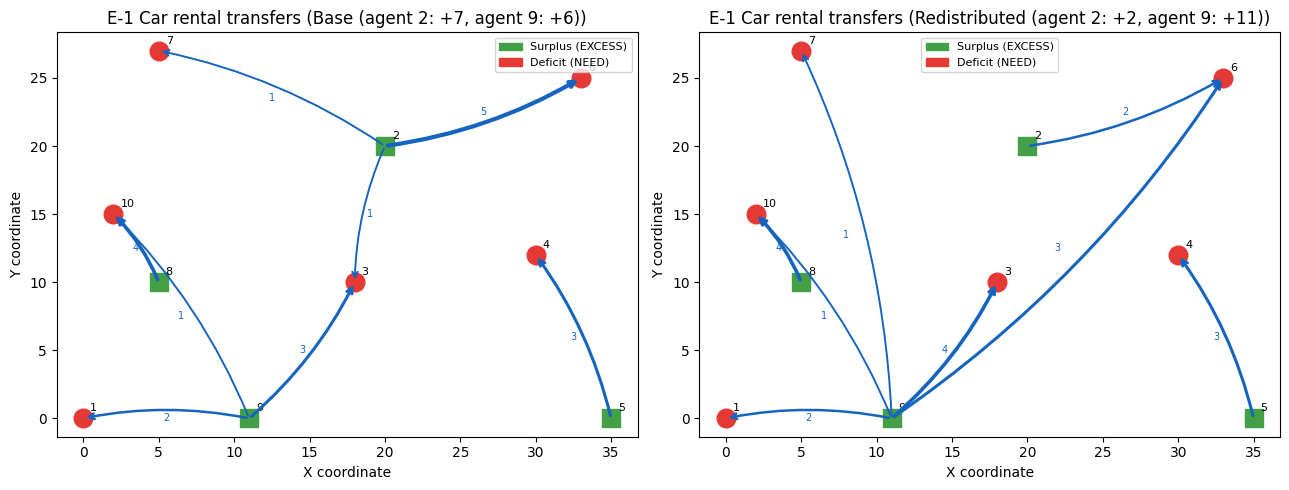

In [ ]:
if "sol_move_base" in locals() and "sol_move_redi" in locals():
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, sol_move, cost_label in [
        (axes[0], sol_move_base, "Base (agent 2: +7, agent 9: +6)"),
        (axes[1], sol_move_redi, "Redistributed (agent 2: +2, agent 9: +11)"),
    ]:
        for a in range(1, 11):
            if a in excess_agents:
                ax.scatter(X[a], Y[a], s=180, color="#43A047", marker="s", zorder=3)
            elif a in need_agents:
                ax.scatter(X[a], Y[a], s=180, color="#E53935", marker="o", zorder=3)
            else:
                ax.scatter(X[a], Y[a], s=100, color="#90CAF9", marker="o", zorder=3)
            ax.annotate(str(a), (X[a], Y[a]), textcoords="offset points",
                        xytext=(5, 5), fontsize=8)

        for (e, n), v in sol_move.items():
            if v > 0.01:
                lw = 1 + v * 0.4
                ax.annotate("", xy=(X[n], Y[n]), xytext=(X[e], Y[e]),
                            arrowprops=dict(arrowstyle="->", color="#1565C0",
                                           lw=lw, connectionstyle="arc3,rad=0.1"))
                mid_x = (X[e] + X[n]) / 2
                mid_y = (Y[e] + Y[n]) / 2
                ax.text(mid_x, mid_y, f"{v:.0f}", fontsize=7, color="#1565C0",
                        ha="center", va="center")

        ax.set_xlabel("X coordinate"); ax.set_ylabel("Y coordinate")
        ax.set_title(f"E-1 Car rental transfers ({cost_label})")

        green_patch = mpatches.Patch(color="#43A047", label="Surplus (EXCESS)")
        red_patch   = mpatches.Patch(color="#E53935", label="Deficit (NEED)")
        ax.legend(handles=[green_patch, red_patch], fontsize=8)

    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping car rental map")

## E-2 Minimum cost flow (LP)

*Applications Book Chapter E, Example 2*

> **Mosel model:** [`e2minflow_p.mos`](models/ground_transport/e2minflow_p.mos)

A transport network connects a single source to three customers (C1, C2, C3) via four depots (D1-D4) using rail and road links. Flow must reach a minimum total throughput of 180 units. Some arcs have minimum and maximum capacity constraints. Transport costs vary by arc. The model minimizes total cost.

**Sets:** $\text{ARCS} = 1..24$, $\text{NODES}$ (auto-built from arc endpoints)

**Decision variables:** $\mathit{flow}_a \geq 0$ for each arc $a$

$$
\begin{align*}
\text{minimize}   \quad & \sum_{a \in \text{ARCS}} \text{COST}_a \cdot \mathit{flow}_a \\
\text{subject to} \quad & \sum_{a:\, A_{a,2}=n} \mathit{flow}_a = \sum_{a:\, A_{a,1}=n} \mathit{flow}_a \quad \forall\, n \notin \{\text{SOURCE},\text{SINK}\} \\
                          & \mathit{flow}_a \geq \text{MINCAP}_a \quad \forall\, a \text{ with minimum capacity} \\
                          & \mathit{flow}_a \leq \text{MAXCAP}_a \quad \forall\, a \text{ with maximum capacity} \\
                          & \sum_{a:\, A_{a,1}=\text{SOURCE}} \mathit{flow}_a \geq \text{MINQ}
\end{align*}
$$

Define arc data in Python. `A` is a 2D dict with keys `(arc_index, 1)` and `(arc_index, 2)` holding the from- and to-node names. `MINCAP`, `MAXCAP`, and `COST` are sparse 1D dicts - only arcs with non-zero values are listed. Passing sparse dicts is efficient: Mosel initializes missing entries to zero automatically.

A `pd.DataFrame` is built from `A` for display.

In [ ]:
A = {
    (1,1):"SOURCE",  (1,2):"D1",
    (2,1):"SOURCE",  (2,2):"D2",
    (3,1):"SOURCE",  (3,2):"D3",
    (4,1):"SOURCE",  (4,2):"D4",
    (5,1):"D1",      (5,2):"road-C1",
    (6,1):"D1",      (6,2):"road-C2",
    (7,1):"D2",      (7,2):"rail-C1",
    (8,1):"D2",      (8,2):"road-C1",
    (9,1):"D3",      (9,2):"road-C2",
    (10,1):"D3",     (10,2):"rail-C3",
    (11,1):"D3",     (11,2):"road-C3",
    (12,1):"D4",     (12,2):"rail-C2",
    (13,1):"D4",     (13,2):"road-C2",
    (14,1):"D4",     (14,2):"rail-C3",
    (15,1):"D4",     (15,2):"road-C3",
    (16,1):"rail-C1",(16,2):"C1",
    (17,1):"road-C1",(17,2):"C1",
    (18,1):"rail-C2",(18,2):"C2",
    (19,1):"road-C2",(19,2):"C2",
    (20,1):"rail-C3",(20,2):"C3",
    (21,1):"road-C3",(21,2):"C3",
    (22,1):"C1",     (22,2):"SINK",
    (23,1):"C2",     (23,2):"SINK",
    (24,1):"C3",     (24,2):"SINK",
}
MINQ    = 180
MINCAP  = {7:10, 10:10, 12:10, 14:10}
MAXCAP  = {1:50, 2:40,  3:35,  4:65,  7:50, 10:50, 12:50, 14:50}
COST_ARC = {5:12, 6:11, 7:12,  8:14,  9:9,  10:4,  11:5,  12:11, 13:14, 14:10, 15:14}

# Build arc DataFrame for display
arc_df = pd.DataFrame(
    {"From": [A[(i,1)] for i in range(1,25)],
     "To":   [A[(i,2)] for i in range(1,25)],
     "MinCap": [MINCAP.get(i, 0) for i in range(1,25)],
     "MaxCap": [MAXCAP.get(i, 0) for i in range(1,25)],
     "Cost":   [COST_ARC.get(i, 0) for i in range(1,25)]},
    index=range(1, 25),
)
arc_df.index.name = "Arc"
print("Network arcs:")
print(arc_df.to_string())

Network arcs:
        From       To  MinCap  MaxCap  Cost
Arc                                        
1     SOURCE       D1       0      50     0
2     SOURCE       D2       0      40     0
3     SOURCE       D3       0      35     0
4     SOURCE       D4       0      65     0
5         D1  road-C1       0       0    12
6         D1  road-C2       0       0    11
7         D2  rail-C1      10      50    12
8         D2  road-C1       0       0    14
9         D3  road-C2       0       0     9
10        D3  rail-C3      10      50     4
11        D3  road-C3       0       0     5
12        D4  rail-C2      10      50    11
13        D4  road-C2       0       0    14
14        D4  rail-C3      10      50    10
15        D4  road-C3       0       0    14
16   rail-C1       C1       0       0     0
17   road-C1       C1       0       0     0
18   rail-C2       C2       0       0     0
19   road-C2       C2       0       0     0
20   rail-C3       C3       0       0     0
21   road-C3      

Use the single execution command. Note how `COST_ARC` is passed under the name `COST` to match the Mosel identifier. After solving, `sol_flow` is a dict mapping arc index to flow value.

In [ ]:
model, output = mp.execute_model(
    f"{MODELS}/e2minflow_p.mos",
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:", "MINQ": MINQ},
    input_data={"A": A, "MINCAP": MINCAP, "MAXCAP": MAXCAP, "COST": COST_ARC},
)

if output is not None:
    obj_val_e2 = output["obj_val"]
    sol_flow   = output["sol_flow"]

    print(f"Minimum cost: {obj_val_e2:.2f}")
    print()
    total_out = sum(sol_flow.get(a, 0) for a in [1,2,3,4])
    print(f"Total flow from SOURCE: {total_out:.1f}  (minimum required: {MINQ})")
    print()
    print(f"{'Arc':>4}  {'From':<12} {'To':<12} {'Flow':>6} {'MinCap':>7} {'MaxCap':>7} {'Cost':>5}")
    for a in range(1, 25):
        flow_a = sol_flow.get(a, 0)
        if flow_a > 0.01:
            print(f"  {a:>2}  {A[(a,1)]:<12} {A[(a,2)]:<12} {flow_a:>6.1f}"
                  f" {MINCAP.get(a,0):>7} {MAXCAP.get(a,0):>7} {COST_ARC.get(a,0):>5}")
else:
    print("No output returned")

Minimum cost: 1715.00

Total flow from SOURCE: 180.0  (minimum required: 180)

 Arc  From         To             Flow  MinCap  MaxCap  Cost
   1  SOURCE       D1             50.0       0      50     0
   2  SOURCE       D2             30.0       0      40     0
   3  SOURCE       D3             35.0       0      35     0
   4  SOURCE       D4             65.0       0      65     0
   6  D1           road-C2        50.0       0       0    11
   7  D2           rail-C1        30.0      10      50    12
  10  D3           rail-C3        35.0      10      50     4
  12  D4           rail-C2        15.0      10      50    11
  14  D4           rail-C3        50.0      10      50    10
  16  rail-C1      C1             30.0       0       0     0
  18  rail-C2      C2             15.0       0       0     0
  19  road-C2      C2             50.0       0       0     0
  20  rail-C3      C3             85.0       0       0     0
  22  C1           SINK           30.0       0       0     0
  23  

Bar chart of arc flows for all arcs carrying positive flow. Arcs are colored by transport mode (SOURCE/sink connectors in gray, rail in blue, road in orange).

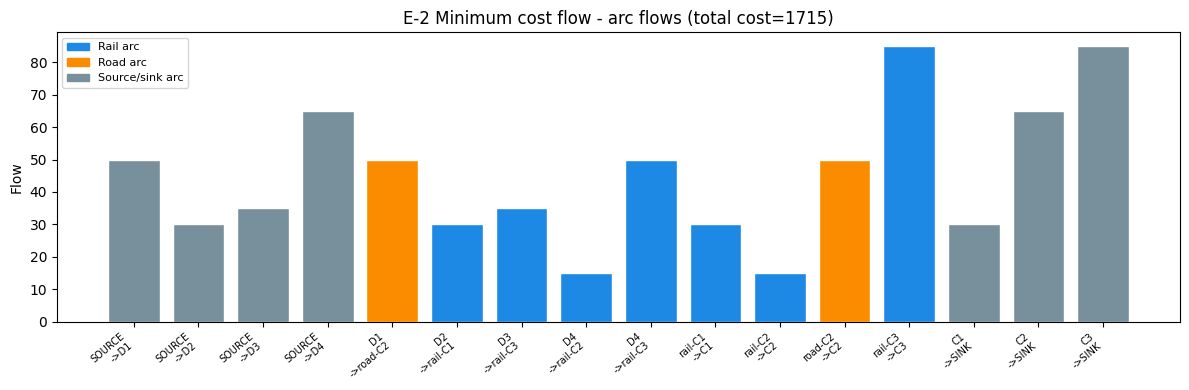

In [ ]:
if "sol_flow" in locals():
    active_arcs = [(a, sol_flow.get(a, 0)) for a in range(1,25) if sol_flow.get(a, 0) > 0.01]

    def arc_color(a):
        from_node = A[(a,1)]
        to_node   = A[(a,2)]
        if "rail" in from_node or "rail" in to_node:
            return "#1E88E5"
        if "road" in from_node or "road" in to_node:
            return "#FB8C00"
        return "#78909C"

    fig, ax = plt.subplots(figsize=(12, 4))
    labels = [f"{A[(a,1)]}\n->{A[(a,2)]}" for a, _ in active_arcs]
    flows  = [f for _, f in active_arcs]
    colors = [arc_color(a) for a, _ in active_arcs]

    bars = ax.bar(range(len(active_arcs)), flows, color=colors, edgecolor="white")
    ax.set_xticks(range(len(active_arcs)))
    ax.set_xticklabels(labels, rotation=40, ha="right", fontsize=7)
    ax.set_ylabel("Flow")
    ax.set_title(f"E-2 Minimum cost flow - arc flows (total cost={obj_val_e2:.0f})")

    rail_patch = mpatches.Patch(color="#1E88E5", label="Rail arc")
    road_patch = mpatches.Patch(color="#FB8C00", label="Road arc")
    gray_patch = mpatches.Patch(color="#78909C", label="Source/sink arc")
    ax.legend(handles=[rail_patch, road_patch, gray_patch], fontsize=8)

    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping flow chart")

## E-3 Depot location (MIP)

*Applications Book Chapter E, Example 3*

> **Mosel model:** [`e3depot_p.mos`](models/ground_transport/e3depot_p.mos)

A company must decide which depots to open (out of 12 candidates) and how to assign 12 customers to open depots. Each depot has a fixed opening cost and a capacity. Transport cost depends on the depot-customer pair. The model minimizes total fixed plus transport cost.

**Sets:** $\text{DEPOTS} = 1..12$, $\text{CUST} = 1..12$

**Decision variables:** $\mathit{build}_d \in \{0,1\}$ (1 if depot $d$ is opened); $\mathit{fflow}_{d,c} \in [0,1]$ (fraction of customer $c$ demand served by depot $d$)

$$
\begin{align*}
\text{minimize}   \quad & \sum_{d} \text{CFIX}_d \cdot \mathit{build}_d + \sum_{d,c} \text{COST}_{d,c} \cdot \text{DEM}_c \cdot \mathit{fflow}_{d,c} \\
\text{subject to} \quad & \sum_{d} \mathit{fflow}_{d,c} = 1 \quad \forall\, c \\
                          & \sum_{c} \text{DEM}_c \cdot \mathit{fflow}_{d,c} \leq \text{CAP}_d \cdot \mathit{build}_d \quad \forall\, d
\end{align*}
$$

Define the 12x12 transport cost matrix as a `pd.DataFrame` with depot indices as rows and customer indices as columns. Passing a DataFrame directly via `input_data` is a convenient way to supply 2D data - MoselPy maps the row and column indices to the Mosel 2D array. Fixed costs `CFIX`, capacities `CAP`, and demands `DEM` are 1-indexed dicts.

In [ ]:
cost_rows = [
    [100, 80,  50,  50,  60,  100, 120, 90,  60,  70,  65,  110],
    [120, 90,  60,  70,  65,  110, 140, 110, 80,  80,  75,  130],
    [140, 110, 80,  80,  75,  130, 160, 125, 100, 100, 80,  150],
    [160, 125, 100, 100, 80,  150, 190, 150, 130, 1e6, 1e6, 1e6],
    [190, 150, 130, 1e6, 1e6, 1e6, 200, 180, 150, 1e6, 1e6, 1e6],
    [200, 180, 150, 1e6, 1e6, 1e6, 100, 80,  50,  50,  60,  100],
    [100, 80,  50,  50,  60,  100, 120, 90,  60,  70,  65,  110],
    [120, 90,  60,  70,  65,  110, 140, 110, 80,  80,  75,  130],
    [140, 110, 80,  80,  75,  130, 160, 125, 100, 100, 80,  150],
    [160, 125, 100, 100, 80,  150, 190, 150, 130, 1e6, 1e6, 1e6],
    [190, 150, 130, 1e6, 1e6, 1e6, 200, 180, 150, 1e6, 1e6, 1e6],
    [200, 180, 150, 1e6, 1e6, 1e6, 100, 80,  50,  50,  60,  100],
]
COST_DF = pd.DataFrame(cost_rows, index=range(1,13), columns=range(1,13))
COST_DF.index.name   = "Depot"
COST_DF.columns.name = "Customer"

CFIX = {1:3500,  2:9000,  3:10000, 4:4000,  5:3000,  6:9000,
        7:9000,  8:3000,  9:4000,  10:10000, 11:9000, 12:3500}
CAP  = {1:300, 2:250, 3:100, 4:180, 5:275, 6:300,
        7:200, 8:220, 9:270, 10:250, 11:230, 12:180}
DEM  = {1:120, 2:80,  3:75,  4:100, 5:110, 6:100,
        7:90,  8:60,  9:30,  10:150, 11:95, 12:120}

print(f"Total demand: {sum(DEM.values())}")
print(f"Total capacity: {sum(CAP.values())}")
print(f"\nCost matrix (first 6 rows/cols, 1e6 = infeasible route):")
print(COST_DF.iloc[:6, :6].to_string())

Total demand: 1130
Total capacity: 2755

Cost matrix (first 6 rows/cols, 1e6 = infeasible route):
Customer    1    2    3          4          5          6
Depot                                                   
1         100   80   50       50.0       60.0      100.0
2         120   90   60       70.0       65.0      110.0
3         140  110   80       80.0       75.0      130.0
4         160  125  100      100.0       80.0      150.0
5         190  150  130  1000000.0  1000000.0  1000000.0
6         200  180  150  1000000.0  1000000.0  1000000.0


Run `e3depot_p.mos` using the compile-load-run sequence, passing `COST_DF` as the 2D cost matrix. After solving, `sol_build` shows which depots are opened and `sol_fflow` gives the fractional assignments of customers to depots.

In [ ]:
mp.compile_model(f"{MODELS}/e3depot_p.mos", f"{MODELS}/e3depot_p.bim")
model = mp.load_model(f"{MODELS}/e3depot_p.bim")
model.set_default_stream(mp.StreamType.OUTPUT, "null:")

output = model.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"COST": COST_DF, "CFIX": CFIX, "CAP": CAP, "DEM": DEM},
)

if model.prob_status.is_solution_available:
    obj_val_e3 = output["obj_val"]
    sol_build  = output["sol_build"]
    sol_fflow  = output["sol_fflow"]

    open_depots = [d for d in range(1, 13) if sol_build.get(d, 0) > 0.5]
    print(f"Minimum total cost: {obj_val_e3:,.0f}")
    print(f"Open depots: {open_depots}")
    print()
    for d in open_depots:
        assigned = {c: sol_fflow.get((d, c), 0) for c in range(1, 13)
                    if sol_fflow.get((d, c), 0) > 0.01}
        load = sum(DEM[c] * v for c, v in assigned.items())
        print(f"  Depot {d} (cap={CAP[d]}, fixed={CFIX[d]:,}): "
              f"load={load:.0f}, customers={list(assigned.keys())}")
else:
    print(f"No solution found ({model.prob_status})")

Minimum total cost: 18,103
Open depots: [1, 5, 8, 9, 12]

  Depot 1 (cap=300, fixed=3,500): load=300, customers=[2, 3, 4, 12]
  Depot 5 (cap=275, fixed=3,000): load=160, customers=[1, 2]
  Depot 8 (cap=220, fixed=3,000): load=220, customers=[2, 6, 10]
  Depot 9 (cap=270, fixed=4,000): load=270, customers=[5, 10, 11]
  Depot 12 (cap=180, fixed=3,500): load=180, customers=[7, 8, 9]


Two-panel visualization: (left) which depots are opened vs closed with their fixed costs; (right) heatmap of the fractional flow assignments from open depots to customers.

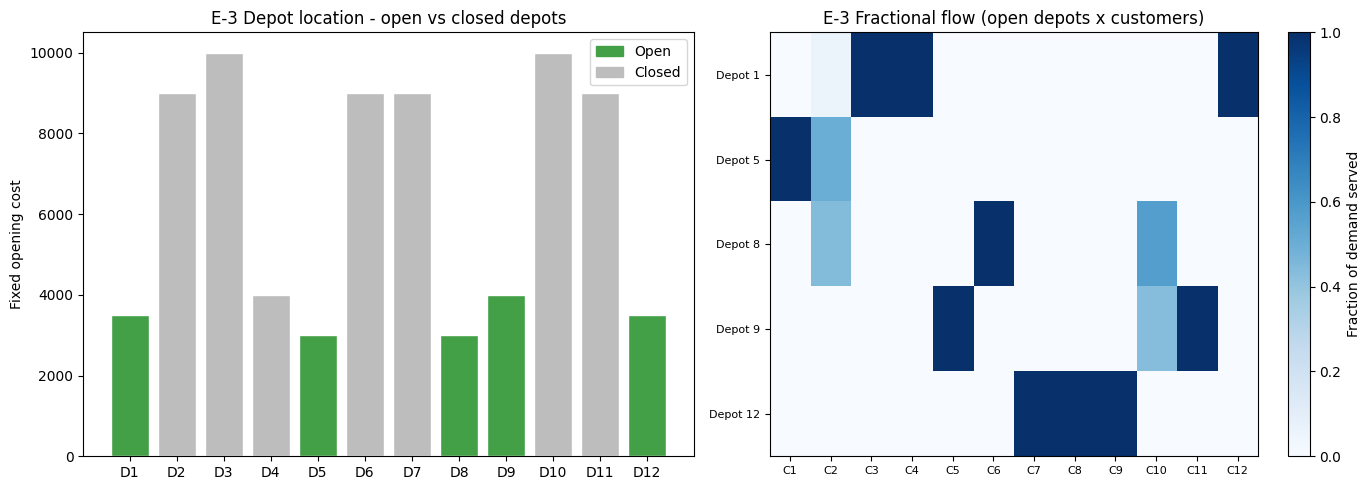

In [ ]:
if "sol_build" in locals():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: depot open/close with fixed costs
    ax = axes[0]
    statuses = [sol_build.get(d, 0) for d in range(1, 13)]
    colors_d  = ["#43A047" if s > 0.5 else "#BDBDBD" for s in statuses]
    bars = ax.bar(range(1, 13), [CFIX[d] for d in range(1, 13)],
                  color=colors_d, edgecolor="white")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels([f"D{d}" for d in range(1, 13)])
    ax.set_ylabel("Fixed opening cost")
    ax.set_title("E-3 Depot location - open vs closed depots")
    open_p  = mpatches.Patch(color="#43A047", label="Open")
    close_p = mpatches.Patch(color="#BDBDBD", label="Closed")
    ax.legend(handles=[open_p, close_p])

    # Right: fractional flow heatmap (open depots only)
    ax2 = axes[1]
    flow_matrix = np.array(
        [[sol_fflow.get((d, c), 0) for c in range(1, 13)] for d in open_depots]
    )
    im = ax2.imshow(flow_matrix, cmap="Blues", aspect="auto", vmin=0, vmax=1)
    plt.colorbar(im, ax=ax2, label="Fraction of demand served")
    ax2.set_xticks(range(12))
    ax2.set_xticklabels([f"C{c}" for c in range(1, 13)], fontsize=8)
    ax2.set_yticks(range(len(open_depots)))
    ax2.set_yticklabels([f"Depot {d}" for d in open_depots], fontsize=8)
    ax2.set_title("E-3 Fractional flow (open depots x customers)")

    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping depot location charts")

## E-4 Heating oil delivery (MIP)

*Applications Book Chapter E, Example 4*

> **Mosel model:** [`e4deliver_p.mos`](models/ground_transport/e4deliver_p.mos)

A delivery truck departs from a depot (site 1) and must visit 6 customers before returning. Each customer has a known demand; the truck has a capacity of 39,000 litres. The model finds the minimum distance tour that satisfies all customer demands without exceeding truck capacity. This is a capacitated vehicle routing / TSP problem.

**Sets:** $\text{SITES} = 1..7$ (site 1 is the depot)

**Decision variables:** $\mathit{prec}_{i,j} \in \{0,1\}$ (1 if site $i$ is visited directly before $j$); $\mathit{cumload}_s \geq 0$ (cumulative load at site $s$)

$$
\begin{align*}
\text{minimize}   \quad & \sum_{i \neq j} \text{DIST}_{i,j} \cdot \mathit{prec}_{i,j} \\
\text{subject to} \quad & \sum_{i \neq j} \mathit{prec}_{i,j} = 1 \quad \forall\, j \quad \text{(enter each site once)} \\
                          & \sum_{j \neq i} \mathit{prec}_{i,j} = 1 \quad \forall\, i \quad \text{(leave each site once)} \\
                          & \mathit{cumload}_j \geq \mathit{cumload}_i + \text{DEM}_j - \text{CAP}(1 - \mathit{prec}_{i,j}) \quad \forall\, i \neq j,\, j > 1
\end{align*}
$$

Define the 7x7 distance matrix `DIST` as a dict with `(i,j)` tuple keys, customer demands `DEM` as a sparse 1-indexed dict (site 1 is the depot with demand 0), and truck capacity `CAP` as a scalar passed via `exec_params`.

In [ ]:
dist_raw = [
    [  0, 148,  55,  32,  70, 140,  73],
    [148,   0,  93, 180,  99,  12,  72],
    [ 55,  93,   0,  85,  20,  83,  28],
    [ 32, 180,  85,   0, 100, 174,  99],
    [ 70,  99,  20, 100,   0,  85,  49],
    [140,  12,  83, 174,  85,   0,  73],
    [ 73,  72,  28,  99,  49,  73,   0],
]
DIST = {(i+1, j+1): dist_raw[i][j] for i in range(7) for j in range(7)}
DEM  = {2:14000, 3:3000, 4:6000, 5:16000, 6:15000, 7:5000}
CAP  = 39000

total_dem = sum(DEM.values())
print(f"Total customer demand: {total_dem:,} litres")
print(f"Truck capacity: {CAP:,} litres")
print(f"Capacity utilization: {100*total_dem/CAP:.1f}%")

Total customer demand: 59,000 litres
Truck capacity: 39,000 litres
Capacity utilization: 151.3%


This section demonstrates `model.stop()` - a MoselPy feature for graceful early termination of a running solve. A background thread waits 5 seconds and then calls `model.stop()` if the model is still running. For this small TSP instance the solver typically finishes well under 5 seconds, so `stop()` will usually not trigger. The pattern is shown regardless: it is essential for larger MIP problems where you want to impose a wall-clock time limit and use the best solution found so far.

After the run, `model.prob_status.is_solution_available` distinguishes between a full optimal solve and an early-terminated solve with an incumbent.

In [ ]:
import threading, time

mp.compile_model(f"{MODELS}/e4deliver_p.mos", f"{MODELS}/e4deliver_p.bim")
model = mp.load_model(f"{MODELS}/e4deliver_p.bim")
model.set_default_stream(mp.StreamType.OUTPUT, "null:")

def stop_after(mdl, seconds):
    time.sleep(seconds)
    if mdl.is_running:
        print(f"[stop_after] {seconds}s elapsed - calling model.stop()")
        mdl.stop()

t = threading.Thread(target=stop_after, args=(model, 5))
t.start()

output = model.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:", "CAP": CAP},
    input_data={"DIST": DIST, "DEM": DEM},
)
t.join()

if model.prob_status.is_solution_available:
    obj_val_e4 = output["obj_val"]
    sol_prec   = output["sol_prec"]

    print(f"Best solution found: {obj_val_e4:.0f} km")

    # Reconstruct tour order starting from depot (site 1)
    tour = [1]
    current = 1
    for _ in range(6):
        nxt = next((j for j in range(1, 8) if j != current and sol_prec.get((current, j), 0) > 0.5), None)
        if nxt is None:
            break
        tour.append(nxt)
        current = nxt
    tour.append(1)  # return to depot

    print(f"Tour: {' -> '.join(str(s) for s in tour)}")
    print()
    for k in range(len(tour)-1):
        s, nxt = tour[k], tour[k+1]
        dem_s  = DEM.get(nxt, 0)
        print(f"  {s} -> {nxt}:  dist={DIST[(s,nxt)]}, demand at {nxt}={dem_s:,}")
else:
    print(f"No solution found ({model.prob_status})")

Best solution found: 497 km
Tour: 1 -> 3 -> 6 -> 2 -> 7 -> 1 -> 3 -> 1

  1 -> 3:  dist=55, demand at 3=3,000
  3 -> 6:  dist=83, demand at 6=15,000
  6 -> 2:  dist=12, demand at 2=14,000
  2 -> 7:  dist=72, demand at 7=5,000
  7 -> 1:  dist=73, demand at 1=0
  1 -> 3:  dist=55, demand at 3=3,000
  3 -> 1:  dist=55, demand at 1=0


Route visualization on a 2D coordinate grid. Sites are plotted at representative positions; arrows show the delivery tour sequence. The depot (site 1) is highlighted.

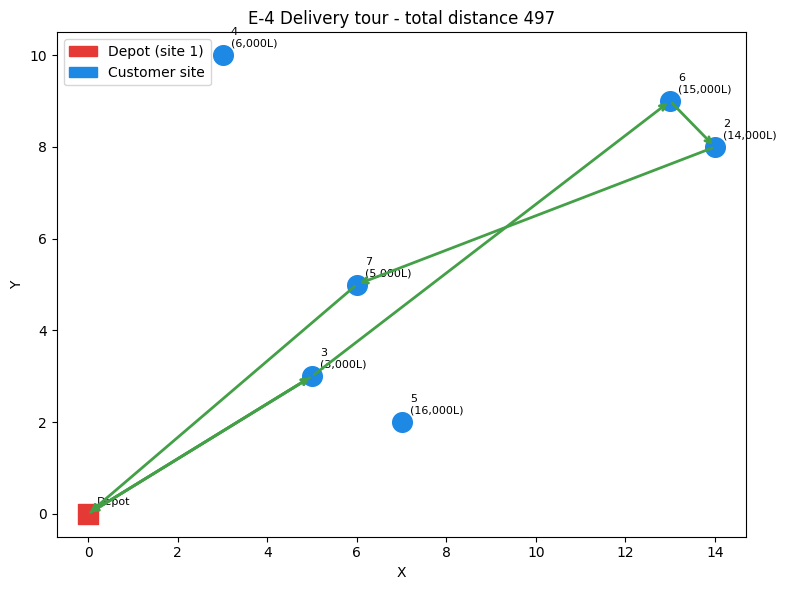

In [ ]:
if "sol_prec" in locals():
    # Representative coordinates for the 7 sites
    coords = {1:(0,0), 2:(14,8), 3:(5,3), 4:(3,10), 5:(7,2), 6:(13,9), 7:(6,5)}
    site_names = {1:"Depot", 2:"C2", 3:"C3", 4:"C4", 5:"C5", 6:"C6", 7:"C7"}

    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot sites
    for s, (cx, cy) in coords.items():
        color = "#E53935" if s == 1 else "#1E88E5"
        marker = "s" if s == 1 else "o"
        ax.scatter(cx, cy, s=200, color=color, marker=marker, zorder=3)
        ax.annotate(f"{s}\n({DEM.get(s,0):,}L)" if s > 1 else "Depot",
                    (cx, cy), textcoords="offset points", xytext=(6, 6), fontsize=8)

    # Draw tour arrows
    if "tour" in locals():
        for k in range(len(tour)-1):
            s, nxt = tour[k], tour[k+1]
            sx, sy = coords[s]
            ex, ey = coords[nxt]
            ax.annotate("", xy=(ex, ey), xytext=(sx, sy),
                        arrowprops=dict(arrowstyle="->", color="#43A047", lw=2.0))

    ax.set_title(f"E-4 Delivery tour - total distance {obj_val_e4:.0f}")
    ax.set_xlabel("X"); ax.set_ylabel("Y")
    depot_p = mpatches.Patch(color="#E53935", label="Depot (site 1)")
    cust_p  = mpatches.Patch(color="#1E88E5", label="Customer site")
    ax.legend(handles=[depot_p, cust_p])
    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping delivery tour chart")

## E-5 Combined transport (MIP)

*Applications Book Chapter E, Example 5*

> **Mosel model:** [`e5combine_p.mos`](models/ground_transport/e5combine_p.mos)

Goods must be transported over four consecutive route legs. Three transport modes - rail, road, and air - are available for each leg, with different costs per leg. Switching between modes between consecutive legs incurs a changeover cost. The model selects one mode per leg to minimize total transport plus changeover cost.

**Sets:** $\text{LEGS} = 1..4$, $\text{MODES} = \{\text{rail},\text{road},\text{air}\}$ (auto-populated from data)

**Decision variables:** $\mathit{use}_{m,l} \in \{0,1\}$ (1 if mode $m$ used on leg $l$); $\mathit{chg}_{m_1,m_2,l} \geq 0$ (1 if switching from $m_1$ to $m_2$ before leg $l$)

$$
\begin{align*}
\text{minimize}   \quad & \sum_{m,l} \text{CTRANS}_{m,l} \cdot \mathit{use}_{m,l} + \sum_{m_1,m_2,l \geq 2} \text{CCHG}_{m_1,m_2} \cdot \mathit{chg}_{m_1,m_2,l} \\
\text{subject to} \quad & \sum_m \mathit{use}_{m,l} = 1 \quad \forall\, l \\
                          & \mathit{chg}_{m_1,m_2,l} \geq \mathit{use}_{m_1,l-1} + \mathit{use}_{m_2,l} - 1 \quad \forall\, m_1 \neq m_2,\, l \geq 2
\end{align*}
$$

Define transport costs `CTRANS` as a `pd.DataFrame` with mode names as rows and leg indices 1..4 as columns. Changeover costs `CCHG` are a dict with `(mode1, mode2)` tuple keys. Passing `CTRANS` as a DataFrame lets MoselPy automatically populate the `MODES` set of strings from the row index.

In [ ]:
ctrans_data = {
    "rail": [30, 25, 40, 60],
    "road": [25, 40, 45, 50],
    "air":  [40, 20, 50, 45],
}
CTRANS_DF = pd.DataFrame(ctrans_data, index=[1,2,3,4]).T
CTRANS_DF.index.name   = "Mode"
CTRANS_DF.columns.name = "Leg"

CCHG = {
    ("rail","road"): 5,  ("rail","air"): 12,
    ("road","rail"): 8,  ("road","air"): 10,
    ("air", "rail"): 15, ("air", "road"): 10,
}

print("Transport costs (mode x leg):")
print(CTRANS_DF.to_string())
print()
print("Changeover costs:")
for (m1, m2), c in CCHG.items():
    print(f"  {m1} -> {m2}: {c}")

Transport costs (mode x leg):
Leg    1   2   3   4
Mode                
rail  30  25  40  60
road  25  40  45  50
air   40  20  50  45

Changeover costs:
  rail -> road: 5
  rail -> air: 12
  road -> rail: 8
  road -> air: 10
  air -> rail: 15
  air -> road: 10


Use the single execution command. `CTRANS_DF` is passed via `input_data` as a DataFrame; MoselPy maps its index (mode names) and columns (leg indices) directly to the Mosel 2D array. The `MODES` set of strings auto-populates from the row labels. After solving, `sol_use` is a dict mapping `(mode, leg)` pairs to 0/1 values.

In [ ]:
model, output = mp.execute_model(
    f"{MODELS}/e5combine_p.mos",
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"CTRANS": CTRANS_DF, "CCHG": CCHG},
)

if output is not None:
    obj_val_e5 = output["obj_val"]
    sol_use    = output["sol_use"]

    print(f"Minimum total cost: {obj_val_e5:.0f}")
    print()
    modes_sorted = sorted(set(m for (m, l) in sol_use))
    selected_modes = {l: m for (m, l), v in sol_use.items() if v > 0.5}
    print("Selected mode per leg:")
    for l in range(1, 5):
        m = selected_modes.get(l, "?")
        trans_cost = CTRANS_DF.at[m, l] if m != "?" else 0
        if l > 1:
            prev_m = selected_modes.get(l-1, "?")
            chg_cost = CCHG.get((prev_m, m), 0) if prev_m != m else 0
            print(f"  Leg {l}: {m:5s}  transport={trans_cost:3d}  changeover from {prev_m}={chg_cost}")
        else:
            print(f"  Leg {l}: {m:5s}  transport={trans_cost:3d}")
else:
    print("No output returned")

Minimum total cost: 150

Selected mode per leg:
  Leg 1: rail   transport= 30
  Leg 2: rail   transport= 25  changeover from rail=0
  Leg 3: rail   transport= 40  changeover from rail=0
  Leg 4: road   transport= 50  changeover from rail=5


Stacked bar chart showing cost breakdown per leg: transport cost (solid) and changeover cost (hatched). Bars are colored by selected transport mode.

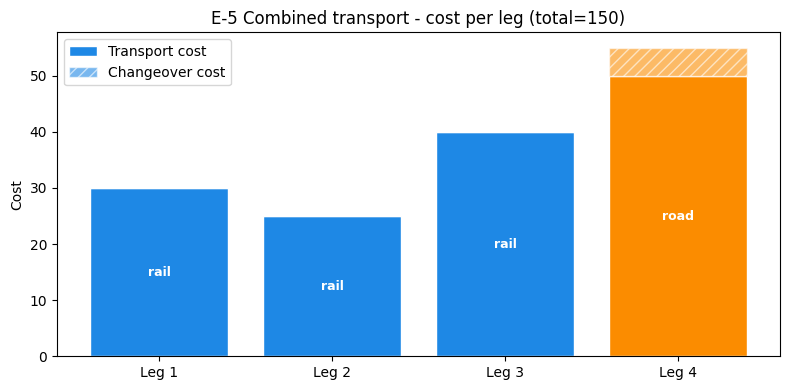

In [ ]:
if "sol_use" in locals():
    selected_modes = {l: m for (m, l), v in sol_use.items() if v > 0.5}
    mode_colors = {"rail": "#1E88E5", "road": "#FB8C00", "air": "#43A047"}

    trans_costs = [CTRANS_DF.at[selected_modes[l], l] for l in range(1, 5)]
    chg_costs   = []
    for l in range(1, 5):
        if l == 1:
            chg_costs.append(0)
        else:
            prev_m = selected_modes.get(l-1, "?")
            curr_m = selected_modes.get(l, "?")
            chg_costs.append(CCHG.get((prev_m, curr_m), 0) if prev_m != curr_m else 0)

    leg_colors = [mode_colors.get(selected_modes.get(l, ""), "#90CAF9") for l in range(1, 5)]

    fig, ax = plt.subplots(figsize=(8, 4))
    x = range(1, 5)
    bars1 = ax.bar(x, trans_costs, color=leg_colors, edgecolor="white",
                   label="Transport cost")
    bars2 = ax.bar(x, chg_costs, bottom=trans_costs, color=leg_colors, edgecolor="white",
                   hatch="///", alpha=0.6, label="Changeover cost")

    for l in range(1, 5):
        mode = selected_modes.get(l, "?")
        ax.text(l, trans_costs[l-1]/2, mode, ha="center", va="center",
                fontsize=9, fontweight="bold", color="white")

    ax.set_xticks(range(1, 5))
    ax.set_xticklabels([f"Leg {l}" for l in range(1, 5)])
    ax.set_ylabel("Cost")
    ax.set_title(f"E-5 Combined transport - cost per leg (total={obj_val_e5:.0f})")
    ax.legend()
    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping combined transport chart")

## E-6 Van rental (MIP)

*Applications Book Chapter E, Example 6*

> **Mosel model:** [`e6vanrent_p.mos`](models/ground_transport/e6vanrent_p.mos)

A company needs vans for six months. Vans may be hired on contracts of 3, 4, or 5 months duration; longer contracts cost less per month. An initial fleet of 200 vans is available for the first three months. The model minimizes total rental cost while meeting monthly demand.

**Sets:** $\text{MONTHS} = 1..6$, $\text{CONTR} = 3..5$ (contract durations)

**Decision variables:** $\mathit{rent}_{c,m} \geq 0$ integer - vans hired on $c$-month contract starting in month $m$

$$
\begin{align*}
\text{minimize}   \quad & \sum_{c \in \text{CONTR},\, m \in \text{MONTHS}} \text{COST}_c \cdot \mathit{rent}_{c,m} \\
\text{subject to} \quad & \text{NINIT} \cdot \mathbf{1}_{m \leq 3} + \sum_{c \in \text{CONTR}} \sum_{s=\max(1,m-c+1)}^{m} \mathit{rent}_{c,s} \geq \text{REQ}_m \quad \forall\, m
\end{align*}
$$

where $\text{NINIT}=200$ is the initial fleet contributing to the first 3 months (on 3-month contracts).

Define monthly requirements `REQ`, contract costs `COST`, and month names `NAMES` in Python. The number of months `NM` and initial fleet `NINIT` can be overridden via `exec_params`, enabling sensitivity analysis.

In [ ]:
REQ   = {1:430, 2:410, 3:440, 4:390, 5:425, 6:450}
COST  = {3:1700, 4:2200, 5:2600}
NAMES = {1:"Jan", 2:"Feb", 3:"Mar", 4:"Apr", 5:"May", 6:"Jun"}
NINIT = 200

print("Monthly van requirements:")
for m, name in NAMES.items():
    print(f"  Month {m} ({name}): {REQ[m]} vans required")
print()
print("Contract costs:", {f"{c}-month": v for c, v in COST.items()})

Monthly van requirements:
  Month 1 (Jan): 430 vans required
  Month 2 (Feb): 410 vans required
  Month 3 (Mar): 440 vans required
  Month 4 (Apr): 390 vans required
  Month 5 (May): 425 vans required
  Month 6 (Jun): 450 vans required

Contract costs: {'3-month': 1700, '4-month': 2200, '5-month': 2600}


### Sensitivity analysis: varying NINIT

The model is compiled and loaded once. `run()` is then called multiple times - each time with a different value of `NINIT` (initial fleet size) via `exec_params`. This is the parametric loop pattern: one compiled model, multiple runs varying a single parameter. Results are collected into a `pd.Series` indexed by `NINIT` value.

As the initial fleet grows, the optimizer can rely on it more heavily for the first three months, reducing the need for new rental contracts and lowering total cost.

In [ ]:
mp.compile_model(f"{MODELS}/e6vanrent_p.mos", f"{MODELS}/e6vanrent_p.bim")
model = mp.load_model(f"{MODELS}/e6vanrent_p.bim")
model.set_default_stream(mp.StreamType.OUTPUT, "null:")

# Base solution at NINIT=200
out_default = model.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:", "NINIT": NINIT},
    input_data={"REQ": REQ, "COST": COST, "NAMES": NAMES},
)

if model.prob_status.is_solution_available:
    obj_val_e6 = out_default["obj_val"]
    sol_rent   = out_default["sol_rent"]   # dict: (contract_len, start_month) -> vans

    NM = 6
    month_names = [NAMES[m] for m in range(1, NM+1)]
    print(f"Total cost: {obj_val_e6:,.0f}")
    print(f"new rents  {'  '.join(f'{n:>4}' for n in month_names)}")
    for c in [3, 4, 5]:
        row = [round(sol_rent.get((c, m), 0)) for m in range(1, NM+1)]
        print(f"{c} months  {'  '.join(f'{v:>4}' for v in row)}")
    totals = [
        (NINIT if m <= 2 else 0) +
        sum(round(sol_rent.get((c, s), 0))
            for c in [3, 4, 5]
            for s in range(max(1, m-c+1), min(m, NM-c+1)+1))
        for m in range(1, NM+1)
    ]
    print(f"Total     {'  '.join(f'{v:>4}' for v in totals)}")
else:
    print(f"No solution found for NINIT={NINIT} ({model.prob_status})")

Total cost: 1,261,000
new rents   Jan   Feb   Mar   Apr   May   Jun
3 months   230     0     0   240     0     0
4 months     0     0   210     0     0     0
5 months     0     0     0     0     0     0
Total      430   430   440   450   450   450


### Sensitivity analysis: varying NINIT

The model is already compiled and loaded. Run it multiple times with different `NINIT` values via `exec_params` - this is the parametric loop pattern. As the initial fleet grows, fewer new rental contracts are needed, reducing total cost.

In [ ]:
ninit_values = [0, 50, 100, 150, 200, 250, 300]
sensitivity_results = {}

for ninit_val in ninit_values:
    out = model.run(
        exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:", "NINIT": ninit_val},
        input_data={"REQ": REQ, "COST": COST, "NAMES": NAMES},
    )
    if model.prob_status.is_solution_available:
        sensitivity_results[ninit_val] = out["obj_val"]
    else:
        print(f"NINIT={ninit_val}: no solution ({model.prob_status})")

cost_series = pd.Series(sensitivity_results, name="Total rental cost")
cost_series.index.name = "NINIT"
print("Total cost vs initial fleet size:")
print(cost_series.apply(lambda v: f"{v:,.0f}").to_string())

Total cost vs initial fleet size:
NINIT
0      1,501,000
50     1,441,000
100    1,381,000
150    1,321,000
200    1,261,000
250    1,201,000
300    1,141,000


Two-panel visualization: (left) sensitivity curve showing total cost vs initial fleet size; (right) stacked bar chart of van contracts per month for the default NINIT=200 solution.

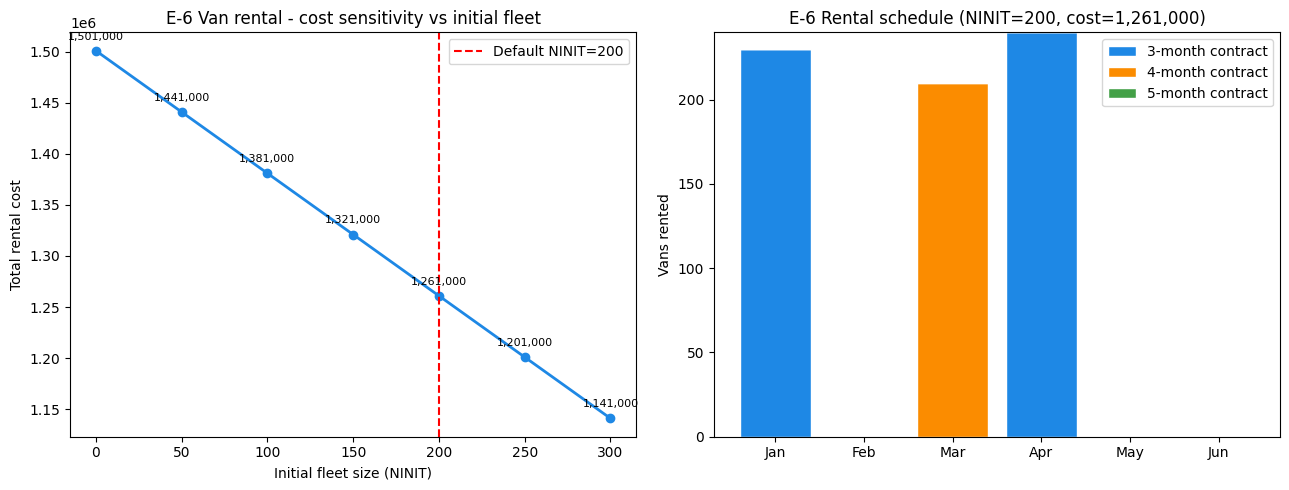

In [ ]:
if cost_series is not None and not cost_series.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Left: sensitivity curve
    ax = axes[0]
    ax.plot(cost_series.index, cost_series.values, marker="o", color="#1E88E5", linewidth=2)
    ax.axvline(NINIT, color="red", linestyle="--", linewidth=1.5, label=f"Default NINIT={NINIT}")
    for x, y in cost_series.items():
        ax.annotate(f"{y:,.0f}", (x, y), textcoords="offset points",
                    xytext=(0, 8), ha="center", fontsize=8)
    ax.set_xlabel("Initial fleet size (NINIT)")
    ax.set_ylabel("Total rental cost")
    ax.set_title("E-6 Van rental - cost sensitivity vs initial fleet")
    ax.legend()

    # Right: contract breakdown for default solution
    ax2 = axes[1]
    if "sol_rent" in locals():
        contract_colors = {3:"#1E88E5", 4:"#FB8C00", 5:"#43A047"}
        bottom = np.zeros(6)
        for c in [3, 4, 5]:
            vals = [sol_rent.get((c, m), 0) for m in range(1, 7)]
            ax2.bar(range(1, 7), vals, bottom=bottom, color=contract_colors[c],
                    edgecolor="white", label=f"{c}-month contract")
            bottom += np.array(vals)

        ax2.set_xticks(range(1, 7))
        ax2.set_xticklabels([NAMES[m] for m in range(1, 7)])
        ax2.set_ylabel("Vans rented")
        ax2.set_title(f"E-6 Rental schedule (NINIT={NINIT}, cost={obj_val_e6:,.0f})")
        ax2.legend()
    else:
        ax2.text(0.5, 0.5, "No solution", ha="center", va="center",
                 transform=ax2.transAxes)

    plt.tight_layout(); plt.show()
else:
    print("No results available - skipping van rental charts")